### Change the location to where the dataset is located

In [1]:
cd /users/nimasha/code/NMF/puer_analysis/data/NMF_analysis

/users/nimasha/code/NMF/puer_analysis/data/NMF_analysis


### Import GeneData.py file where all the functions are defined

In [2]:
from GeneData import* 


$\newcommand{\mean}[1]{\langle #1 \rangle}$
$\newcommand{\bra}[1]{\langle #1 \rvert}$
$\newcommand{\ket}[1]{\lvert #1 \rangle}$
$\newcommand{\adag}{a^\dagger}$
$\newcommand{\mat}[1]{\underline{\underline{\mathbf{#1}}}}$
$\newcommand{\beq}{\qquad\begin{align}}$
$\newcommand{\eeq}{\end{align}}$
$\newcommand{\half}{\frac{1}{2}}$



$\newcommand{\mean}[1]{\langle #1 \rangle}$
$\newcommand{\bra}[1]{\langle #1 \rvert}$
$\newcommand{\ket}[1]{\lvert #1 \rangle}$
$\newcommand{\adag}{a^\dagger}$
$\newcommand{\mat}[1]{\underline{\underline{\mathbf{#1}}}}$
$\newcommand{\beq}{\qquad\begin{align}}$
$\newcommand{\eeq}{\end{align}}$
$\newcommand{\half}{\frac{1}{2}}$


### Read and load tusi data in the csv file

#### Here "tusi_data" is returned as a numpy array, where rows are samples/cells and columns are genes

In [3]:
with open('tusi_harmonizedwithPUER.csv', newline='') as csvfile:
    tusi_data = []
    reader = csv.reader(csvfile)   #reader object iterates through the csv file  
    for row in reader:
        tusi_data.append (row)          #loading data 
    tusi_data = np.array(tusi_data)
    tusi_data = tusi_data.astype(float)

In [4]:
tusi_data.__class__, tusi_data.dtype, tusi_data.shape

(numpy.ndarray, dtype('float64'), (4763, 26398))

### Read and load original coordinates for Tusi data ("tusi_orig_coord")

In [5]:
tusi_orig_coord = np.loadtxt("/users/nimasha/code/NMF/SPRING/datasets/Tusi/origtusicoords.txt", delimiter=",")

In [6]:
tusi_orig_coord.shape

(4763, 3)

#### Multiplying x-axis values with -1, to arrange the Tusi coordinates in the format in Tusi et al.

In [7]:
tusi_orig_coord[:,1] *= -1

In [8]:
tusi_orig_coord.shape

(4763, 3)

In [9]:
tusi_orig_coord

array([[ 0.0000e+00, -2.5590e+02, -3.8559e+02],
       [ 1.0000e+00, -3.0310e+02, -4.9871e+02],
       [ 2.0000e+00, -2.3313e+02, -3.1620e+02],
       ...,
       [ 4.7600e+03, -3.8780e+02, -9.3109e+02],
       [ 4.7610e+03,  1.0716e+03, -1.6690e+02],
       [ 4.7620e+03,  3.2503e+02,  1.9044e+02]])

### Running NMF

#### X_g_samples is a numpy array used for NMF, where genes are rows and columns are samples/cells

In [35]:
X_g_samples = np.array(tusi_data.T)
X_g_samples.shape

(26398, 4763)

#### Normalize X matrix

In [9]:
X_g_samples_normalized = np.zeros(X_g_samples.shape) 
for i in range(0,4763):
    X_g_samples_normalized[:,i] = X_g_samples[:,i] / (max(X_g_samples[:,i]) + 1e-300)

#### Run NMF with given number of behaviors

In [10]:
start_time = time.time()
W_g_m_normalized,H_m_samples_normalized,Frob_norm = NMF(X_g_samples_normalized, 17 , 0.05) 
end_time = time.time()
print("Time :", (end_time - start_time))

iteration=49   FrobNorm=105.04870025955996
Time : 124.56788086891174


#### Save H matrix as a csv file

In [11]:
with open('H_m_samples_normalized_17_behaviors_new.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(H_m_samples_normalized)

#### Load saved csv file with H matrix and plot Spring plots

In [16]:
behaviorExpr_scaled_17 = np.genfromtxt('/users/nimasha/code/NMF/puer_analysis/data/NMF_analysis/H_m_samples_normalized_17_behaviors_new.csv', delimiter=',')
behaviorExpr_scaled_17 = behaviorExpr_scaled_17.transpose()

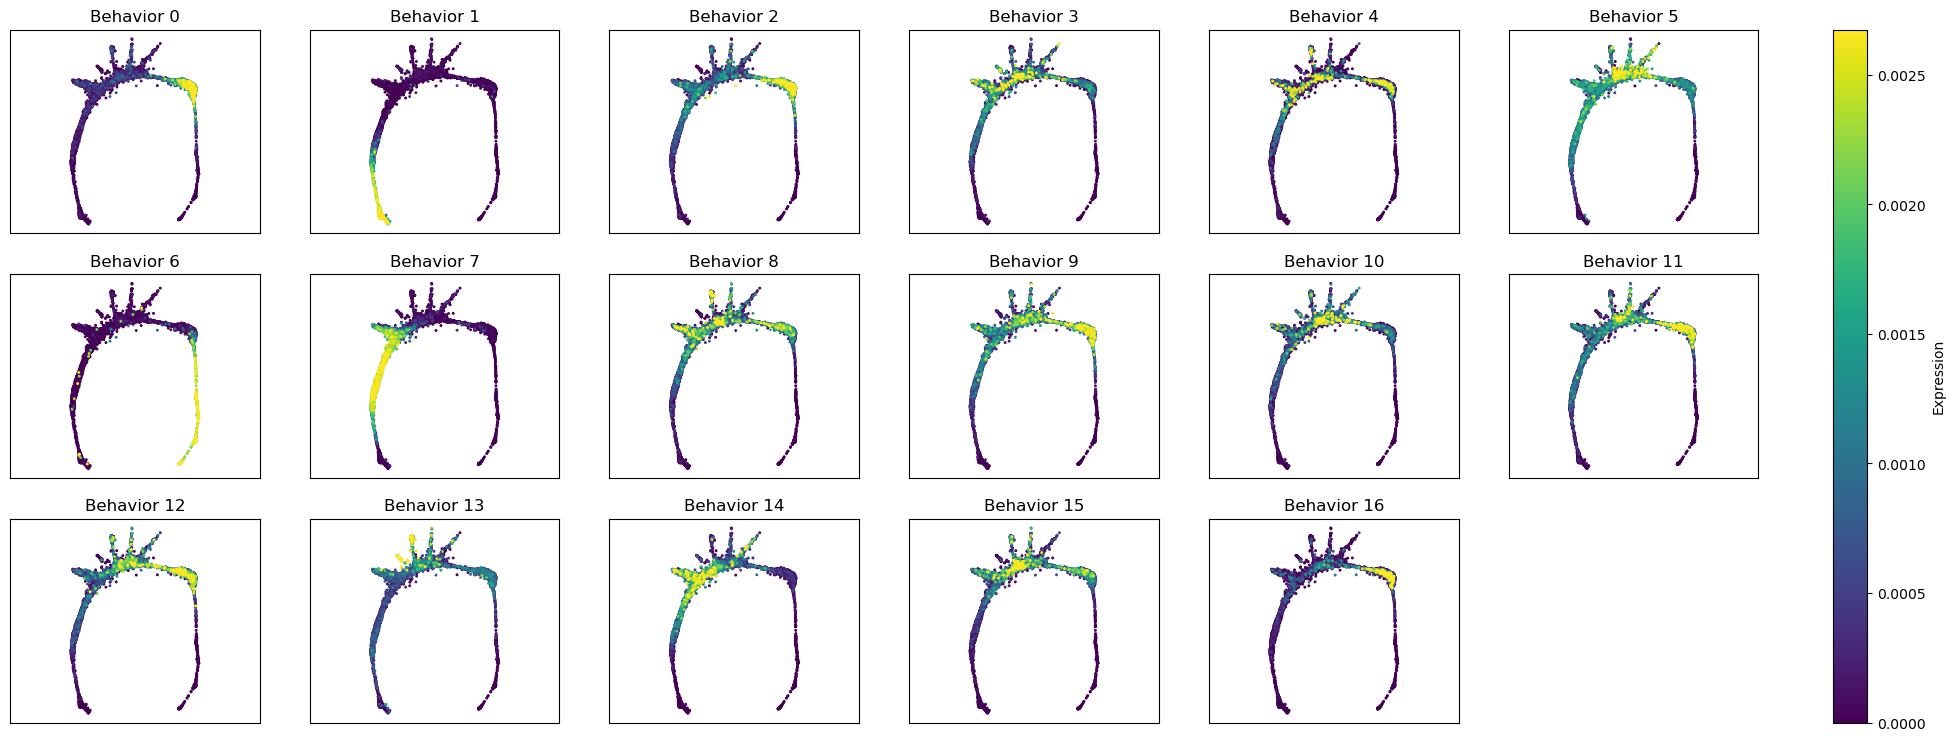

In [17]:
Tusi_scaled_17_behaviors = plotMultipleTusiBehaviors(behaviorExpr_scaled_17,tusi_orig_coord, 6, 3, 99)

#### Save figure as a pdf

In [37]:
Tusi_scaled_17_behaviors.savefig("Tusi_scaled_17_behaviors.pdf", format="pdf", bbox_inches = "tight")

#### Plot a single behavior at a time

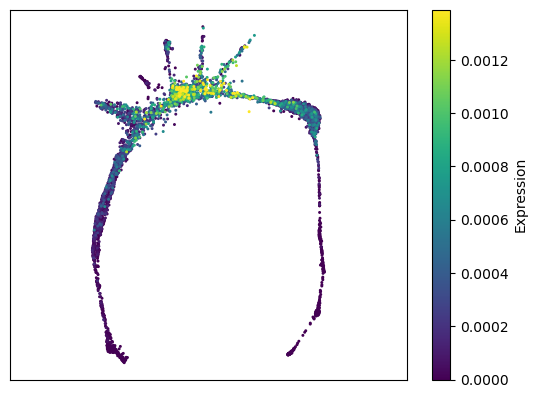

In [30]:
Tusi_single_behavior_scaled_17 = plotTusiBehavior(behaviorExpr_scaled_17[:,4], tusi_orig_coord, None, 99)

### List of the gene names in Tusi data set as a numpy array

In [31]:
Gene_names = ReadGeneNames('tusi_harmonizedwithPUER_genelist.csv')
Gene_names = np.array(Gene_names)

In [25]:
Gene_names = Gene_names.T

### Obtaining gene names list for all metagene beahvior

#### First W indices are sorted in descending order. 

In [27]:
w_meta_sortindices = np.argsort(W_g_m_normalized, axis=0)[::-1] # "w_meta_sortindices" is an array of indices that sort w_meta, along axis 0 in descending order

#### Here 'gene_names' is a numpy array of size 26398 * 17. "gene_names" is sorted gene names according to the indices of the sorted W matrix

In [29]:
gene_names = Gene_names[w_meta_sortindices]      # 